Loaded EEG segment: 106944 samples x 32 channels
Sampled states: 12000
Density threshold (q=0.90): 5.325444
Kept states after density filtering: 10800 / 12000


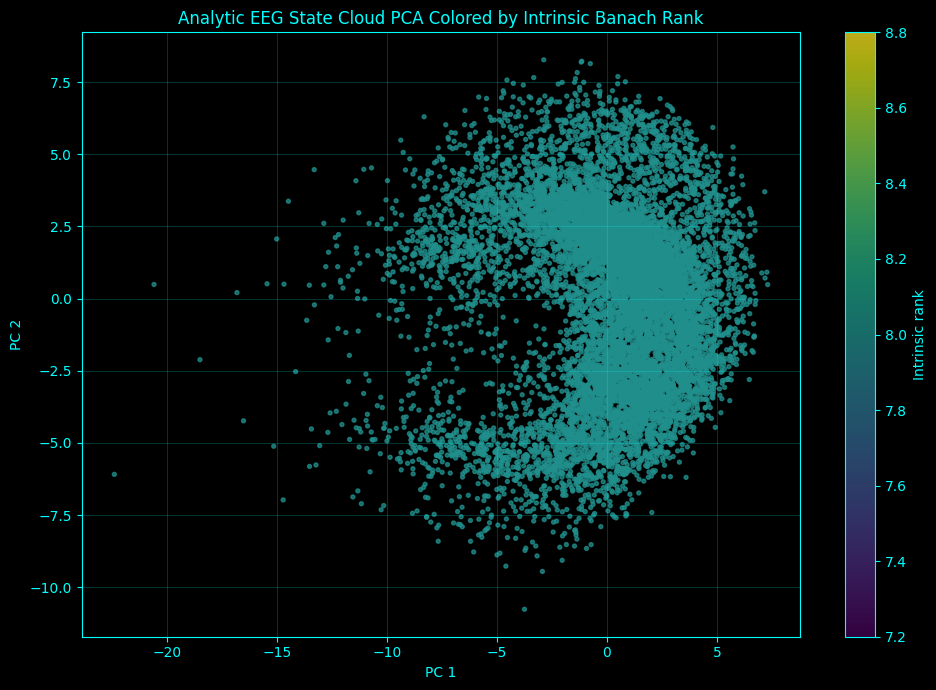

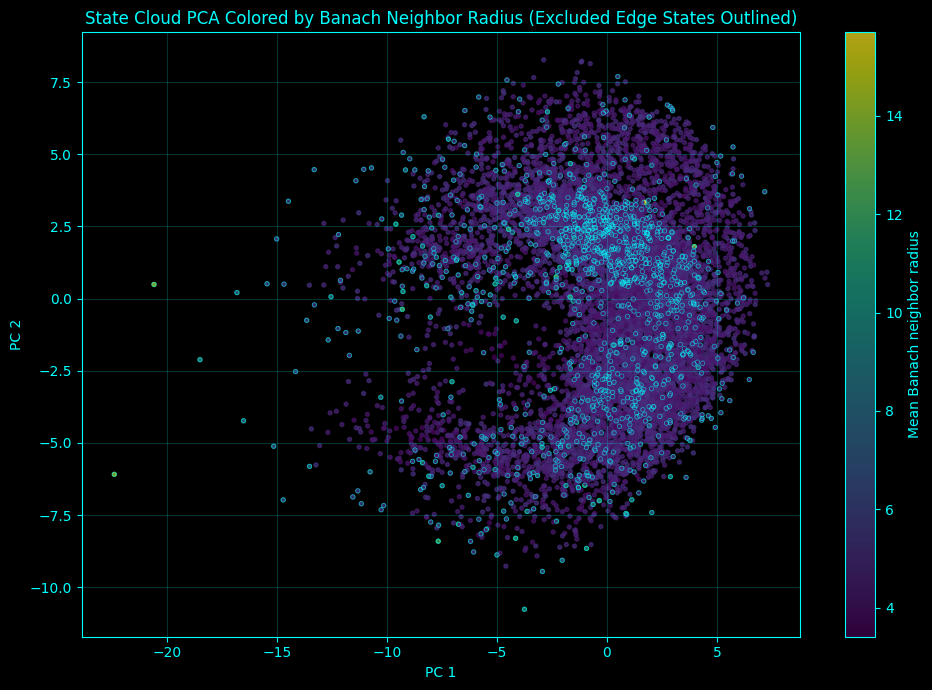

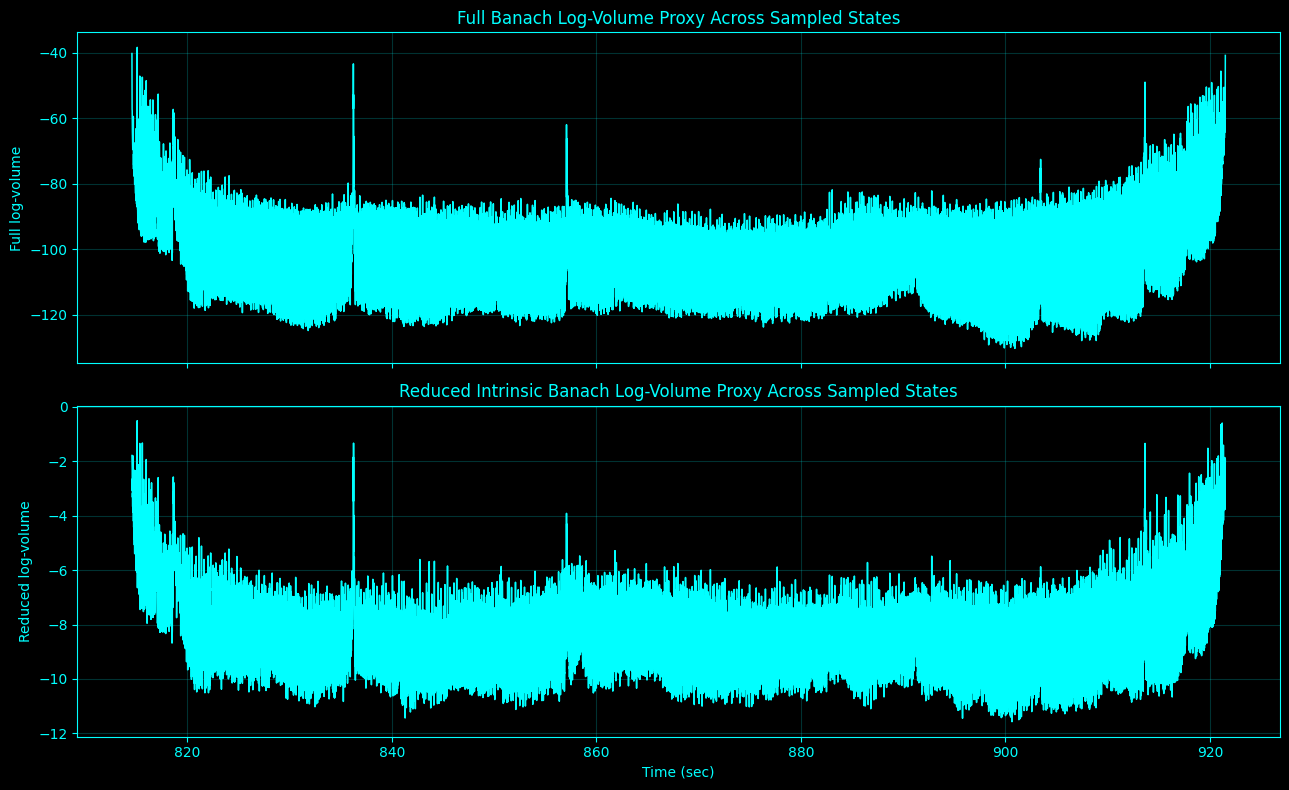

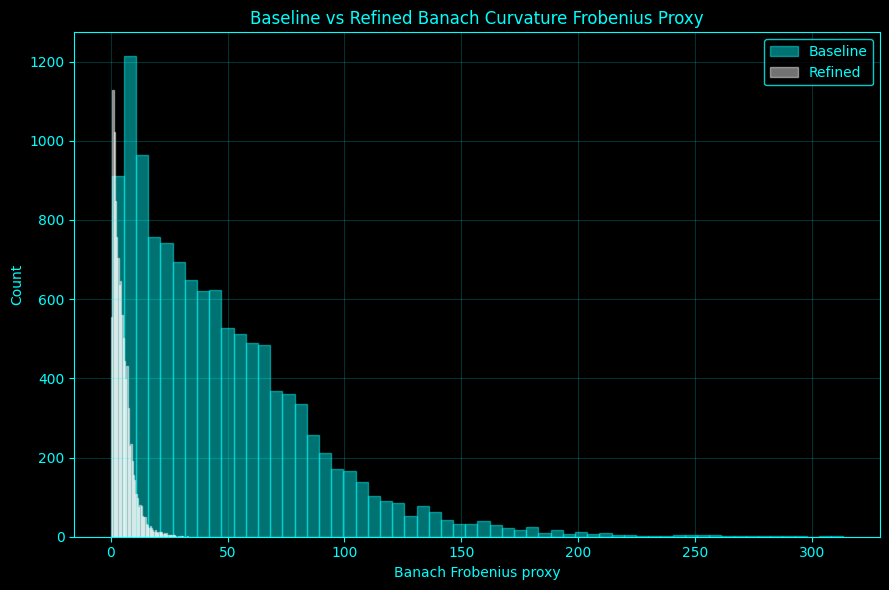

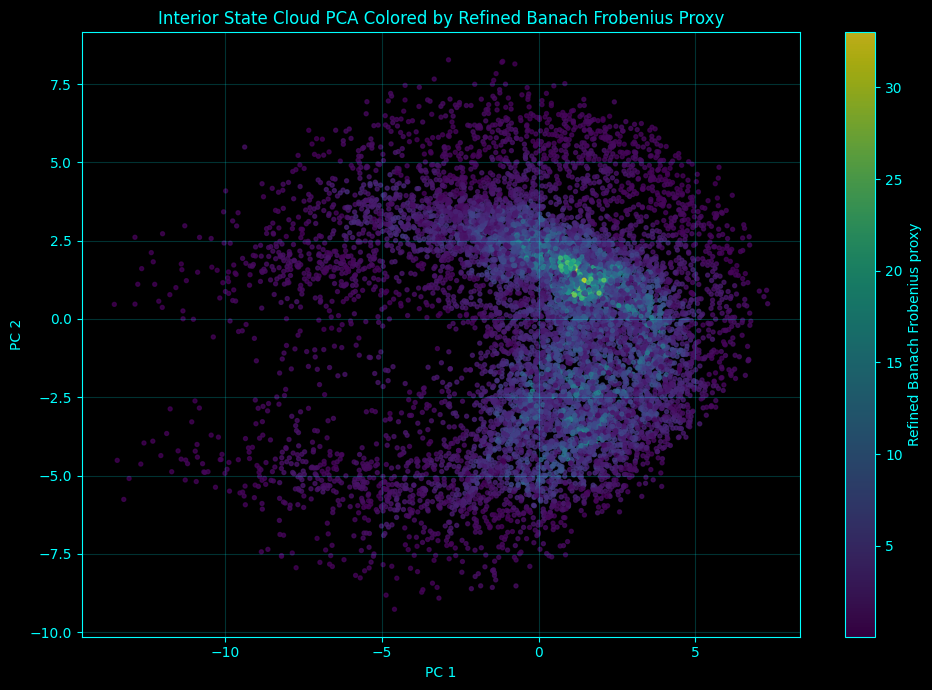

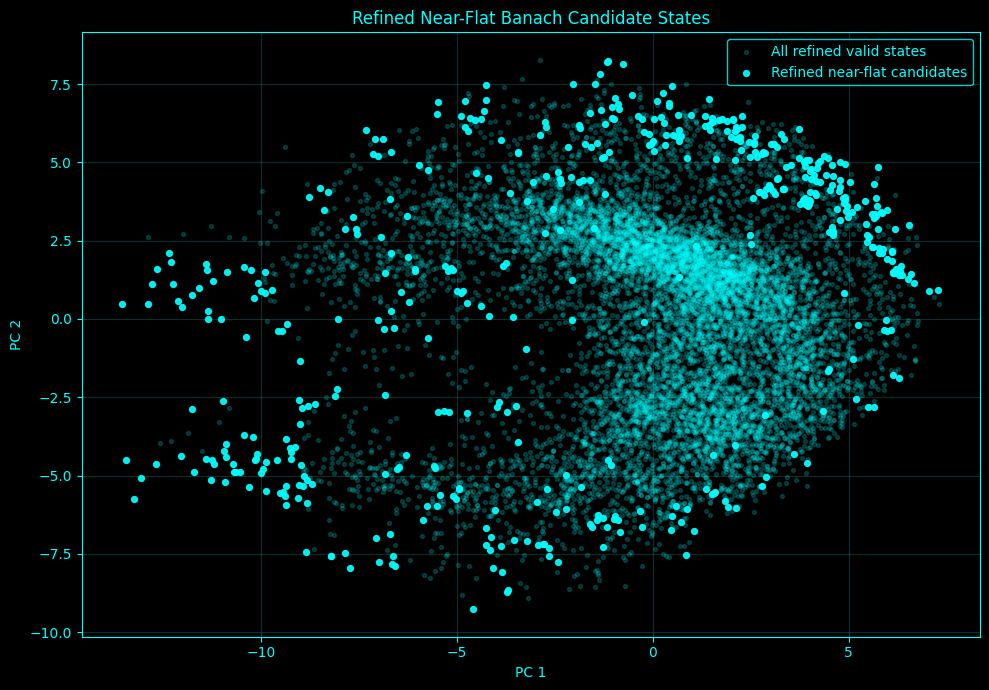


Saved state summary CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/banach_state_summary.csv
Saved baseline Banach curvature CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_banach_curvature_per_state.csv
Saved refined Banach curvature CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/refined_banach_curvature_per_state.csv
Saved baseline near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_banach_near_flat_states.csv
Saved refined near-flat CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/refined_banach_near_flat_states.csv
Saved comparison CSV: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/baseline_vs_refined_banach_comparison.csv
Saved NPZ: /home/a/projects/Complete-Neural-Signal-Analysis/results/banach_intrinsic_curvature/ba

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert
from scipy.spatial import cKDTree

# -------------------------------------------------------
# CONFIG
# -------------------------------------------------------
base_dir = "/home/a/projects/Complete-Neural-Signal-Analysis"
eeg_path = os.path.join(base_dir, "eeg_data_with_channels.npy")

out_dir = os.path.join(base_dir, "results", "banach_intrinsic_curvature")
plots_dir = os.path.join(out_dir, "plots")
os.makedirs(out_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

sampling_rate = 1000
dt = 1.0 / sampling_rate

start_time, end_time = 814.571, 921.515
start_index, end_index = int(start_time * sampling_rate), int(end_time * sampling_rate)

# State-cloud sampling
max_state_points = 12000
rng_seed = 42

# Local neighborhood controls
k_metric_neighbors = 80
scale_reg = 1e-6

# Intrinsic basis controls
intrinsic_energy_threshold = 0.90
min_intrinsic_rank = 2
max_intrinsic_rank = 8

# Density filtering
density_keep_quantile = 0.90   # keep states with Banach neighbor radius <= this quantile

# Local scalar curvature-proxy fit controls
k_curvature_neighbors = 100
min_fit_neighbors = 12

# Banach / Finsler-style local norm controls
banach_p = 4.0                 # p != 2 moves away from Hilbert geometry
scale_method = "mad"           # "mad" or "rms"

ACCENT = "cyan"
BG = "black"
eps = 1e-12

eeg_channel_names = [
    'Fp1', 'Fpz', 'Fp2', 'F7', 'F3', 'Fz', 'F4', 'F8', 'FC5', 'FC1', 'FC2', 'FC6',
    'M1', 'T7', 'C3', 'Cz', 'C4', 'T8', 'M2', 'CP5', 'CP1', 'CP2', 'CP6',
    'P7', 'P3', 'Pz', 'P4', 'P8', 'POz', 'O1', 'Oz', 'O2'
]

plt.rcParams.update({
    "figure.facecolor": BG,
    "axes.facecolor": BG,
    "savefig.facecolor": BG,
    "text.color": ACCENT,
    "axes.labelcolor": ACCENT,
    "axes.edgecolor": ACCENT,
    "axes.titlecolor": ACCENT,
    "xtick.color": ACCENT,
    "ytick.color": ACCENT,
    "grid.color": ACCENT,
    "legend.facecolor": BG,
    "legend.edgecolor": ACCENT,
})

# -------------------------------------------------------
# STYLE
# -------------------------------------------------------
def style_ax(ax):
    ax.set_facecolor(BG)
    ax.tick_params(colors=ACCENT)
    ax.grid(True, alpha=0.20, color=ACCENT)
    for spine in ax.spines.values():
        spine.set_color(ACCENT)

# -------------------------------------------------------
# HELPERS
# -------------------------------------------------------
def ensure_time_channel_layout(x, n_channels_expected):
    x = np.asarray(x, dtype=float)

    if x.ndim != 2:
        raise ValueError(f"Expected 2D EEG array, got shape {x.shape}")

    if x.shape[1] == n_channels_expected:
        return x
    if x.shape[0] == n_channels_expected:
        return x.T

    raise ValueError(f"Unexpected EEG shape: {x.shape}")

def complex_zscore_by_channel(z):
    z = np.asarray(z, dtype=np.complex128)
    mu = np.mean(z, axis=0, keepdims=True)
    zc = z - mu
    rms = np.sqrt(np.mean(np.abs(zc) ** 2, axis=0, keepdims=True))
    return zc / (rms + eps)

def realify_complex_states(Z):
    return np.concatenate([np.real(Z), np.imag(Z)], axis=1)

def uniform_subsample_indices(n, max_n):
    if max_n is None or n <= max_n:
        return np.arange(n, dtype=int)
    return np.linspace(0, n - 1, max_n).astype(int)

def normalized_eig_entropy(vals):
    vals = np.asarray(vals, dtype=float)
    vals = vals[vals > 0]
    if len(vals) == 0:
        return np.nan
    p = vals / (np.sum(vals) + eps)
    H = -np.sum(p * np.log(p + eps))
    Hmax = np.log(len(p) + eps)
    return float(H / (Hmax + eps))

def participation_ratio(vals):
    vals = np.asarray(vals, dtype=float)
    return float((np.sum(vals) ** 2) / (np.sum(vals ** 2) + eps))

def pca_2d(X):
    X = np.asarray(X, dtype=float)
    Xc = X - np.mean(X, axis=0, keepdims=True)
    C = (Xc.T @ Xc) / max(len(Xc) - 1, 1)
    w, V = np.linalg.eigh(C)
    idx = np.argsort(w)[::-1][:2]
    Y = Xc @ V[:, idx]
    return Y, w[idx], V[:, idx]

def choose_intrinsic_rank(eigvals_desc, energy_threshold=0.90, min_rank=2, max_rank=8):
    eigvals_desc = np.asarray(eigvals_desc, dtype=float)
    total = np.sum(eigvals_desc)
    if total <= 0:
        return min_rank
    cume = np.cumsum(eigvals_desc) / total
    r = int(np.searchsorted(cume, energy_threshold) + 1)
    r = max(min_rank, r)
    r = min(max_rank, r, len(eigvals_desc))
    return r

def local_coordinate_scales(X_local, reg=1e-6, method="mad"):
    """
    Robust local coordinate scales for a weighted L^p norm field.
    """
    X_local = np.asarray(X_local, dtype=float)

    if X_local.ndim != 2:
        raise ValueError(f"Expected 2D local offsets, got shape {X_local.shape}")
    if X_local.shape[0] == 0:
        raise ValueError("Empty local neighborhood")

    if method == "mad":
        ctr = np.median(X_local, axis=0, keepdims=True)
        dev = np.abs(X_local - ctr)
        scales = 1.4826 * np.median(dev, axis=0)
    elif method == "rms":
        ctr = np.mean(X_local, axis=0, keepdims=True)
        dev = X_local - ctr
        scales = np.sqrt(np.mean(dev ** 2, axis=0))
    else:
        raise ValueError("method must be 'mad' or 'rms'")

    return np.maximum(scales, reg)

def weighted_lp_norm(V, scales, p=4.0):
    """
    Weighted L^p norm with diagonal local scale field:
        ||v|| = (sum_j |v_j / s_j|^p)^(1/p)
    """
    V = np.asarray(V, dtype=float)
    scales = np.asarray(scales, dtype=float)

    if V.ndim == 1:
        V = V[None, :]

    return np.power(np.sum(np.abs(V / (scales + eps)) ** p, axis=1) + eps, 1.0 / p)

def local_banach_summary(
    X_local,
    p=4.0,
    reg=1e-6,
    method="mad",
    energy_threshold=0.90,
    min_rank=2,
    max_rank=8,
):
    """
    Summarize a local Banach/Finsler-style chart using weighted coordinate scales.
    """
    scales = local_coordinate_scales(X_local, reg=reg, method=method)
    scales_desc = np.sort(scales)[::-1]

    # Use scale^p as the local "energy profile" for intrinsic-rank heuristics.
    scale_energy_desc = np.sort(scales ** p)[::-1]

    intrinsic_rank = choose_intrinsic_rank(
        scale_energy_desc,
        energy_threshold=energy_threshold,
        min_rank=min_rank,
        max_rank=max_rank,
    )

    full_logvol = float(np.sum(np.log(scales_desc + eps)))
    reduced_logvol = float(np.sum(np.log(scales_desc[:intrinsic_rank] + eps)))
    full_trace = float(np.sum(scales_desc))
    reduced_trace = float(np.sum(scales_desc[:intrinsic_rank]))

    full_anisotropy = float(
        (scales_desc[0] - scales_desc[-1]) /
        (scales_desc[0] + scales_desc[-1] + eps)
    )

    reduced_anisotropy = float(
        (scales_desc[0] - scales_desc[intrinsic_rank - 1]) /
        (scales_desc[0] + scales_desc[intrinsic_rank - 1] + eps)
    )

    return {
        "scales": scales,
        "intrinsic_rank": intrinsic_rank,
        "full_logvol_B": full_logvol,
        "reduced_logvol_B": reduced_logvol,
        "full_trace_B": full_trace,
        "reduced_trace_B": reduced_trace,
        "full_anisotropy_B": full_anisotropy,
        "reduced_anisotropy_B": reduced_anisotropy,
        "scale_entropy_B": normalized_eig_entropy(scale_energy_desc),
        "participation_ratio_B": participation_ratio(scale_energy_desc),
    }

def local_transition_distortion(X, local_scales_array, neighbor_idx, p=4.0):
    """
    Measures how much neighboring local Banach norms disagree on shared directions.
    Lower means more chart-to-chart compatibility.
    """
    X = np.asarray(X, dtype=float)
    n = len(X)
    out = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(neighbor_idx[i])
        idx = idx[idx != i]
        if len(idx) == 0:
            continue

        vals = []
        for j in idx:
            v_ij = X[j] - X[i]
            d_i = weighted_lp_norm(v_ij, local_scales_array[i], p=p)[0]
            d_j = weighted_lp_norm(-v_ij, local_scales_array[j], p=p)[0]
            vals.append(np.abs(d_i - d_j) / (0.5 * (d_i + d_j) + eps))

        out[i] = float(np.mean(vals))

    return out

def local_quadratic_banach_curvature_proxy(X2, values, k=100, min_neighbors=12):
    """
    Local quadratic fit to a scalar field on a 2D chart:
        f ≈ a + b x + c y + d x^2 + e xy + f y^2

    Hessian proxy:
        [[2d, e],
         [ e, 2f]]

    This is a Banach volume-distortion curvature proxy, not a true Ricci tensor.
    """
    X2 = np.asarray(X2, dtype=float)
    values = np.asarray(values, dtype=float)
    n = len(X2)

    tree = cKDTree(X2)
    _, nbr_idx = tree.query(X2, k=min(k + 1, n))

    grad_x = np.full(n, np.nan, dtype=float)
    grad_y = np.full(n, np.nan, dtype=float)
    h_xx = np.full(n, np.nan, dtype=float)
    h_xy = np.full(n, np.nan, dtype=float)
    h_yy = np.full(n, np.nan, dtype=float)
    laplacian = np.full(n, np.nan, dtype=float)
    frob = np.full(n, np.nan, dtype=float)
    detv = np.full(n, np.nan, dtype=float)
    eig_small = np.full(n, np.nan, dtype=float)
    eig_large = np.full(n, np.nan, dtype=float)
    fit_r2 = np.full(n, np.nan, dtype=float)
    mean_neighbor_radius = np.full(n, np.nan, dtype=float)

    for i in range(n):
        idx = np.atleast_1d(nbr_idx[i])
        idx = idx[idx != i]

        good = idx[np.isfinite(values[idx])]
        if len(good) < min_neighbors:
            continue

        Xi = X2[good] - X2[i]
        yi = values[good]

        x = Xi[:, 0]
        y = Xi[:, 1]

        A = np.column_stack([
            np.ones(len(Xi)),
            x,
            y,
            x * x,
            x * y,
            y * y
        ])

        try:
            coef, *_ = np.linalg.lstsq(A, yi, rcond=None)
        except np.linalg.LinAlgError:
            continue

        y_hat = A @ coef
        ss_res = np.sum((yi - y_hat) ** 2)
        ss_tot = np.sum((yi - np.mean(yi)) ** 2)
        fit_r2[i] = 1.0 - ss_res / (ss_tot + eps)

        b = coef[1]
        c = coef[2]
        d = coef[3]
        e = coef[4]
        f = coef[5]

        H = np.array([
            [2.0 * d, e],
            [e, 2.0 * f]
        ], dtype=float)

        w = np.linalg.eigvalsh(H)

        grad_x[i] = b
        grad_y[i] = c
        h_xx[i] = H[0, 0]
        h_xy[i] = H[0, 1]
        h_yy[i] = H[1, 1]
        laplacian[i] = np.trace(H)
        frob[i] = np.linalg.norm(H, ord="fro")
        detv[i] = np.linalg.det(H)
        eig_small[i] = w[0]
        eig_large[i] = w[1]
        mean_neighbor_radius[i] = float(np.mean(np.linalg.norm(Xi, axis=1)))

    return pd.DataFrame({
        "grad_x": grad_x,
        "grad_y": grad_y,
        "h_xx": h_xx,
        "h_xy": h_xy,
        "h_yy": h_yy,
        "banach_laplacian_proxy": laplacian,
        "banach_frobenius_proxy": frob,
        "banach_det_proxy": detv,
        "banach_eig_small": eig_small,
        "banach_eig_large": eig_large,
        "banach_fit_r2": fit_r2,
        "banach_chart_neighbor_radius": mean_neighbor_radius,
    })

def safe_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.mean(x)) if len(x) > 0 else np.nan

def safe_median(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.median(x)) if len(x) > 0 else np.nan

def safe_quantile(x, q):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    return float(np.quantile(x, q)) if len(x) > 0 else np.nan

# -------------------------------------------------------
# LOAD EEG AND BUILD ANALYTIC STATE CLOUD
# -------------------------------------------------------
EEG_data = np.load(eeg_path, allow_pickle=True)
EEG_data = ensure_time_channel_layout(EEG_data, len(eeg_channel_names))
EEG_segment = EEG_data[start_index:end_index, :]

n_samples, n_channels = EEG_segment.shape
time_sec = start_time + np.arange(n_samples) * dt

analytic_EEG = hilbert(EEG_segment, axis=0)
analytic_EEG = complex_zscore_by_channel(analytic_EEG)

sample_idx = uniform_subsample_indices(n_samples, max_state_points)
Z_sample = analytic_EEG[sample_idx, :]
T_sample = time_sec[sample_idx]
X_real = realify_complex_states(Z_sample)

pca_xy, pca_eigs, _ = pca_2d(X_real)

print(f"Loaded EEG segment: {n_samples} samples x {n_channels} channels")
print(f"Sampled states: {len(sample_idx)}")

# -------------------------------------------------------
# LOCAL BANACH / FINSLER-STYLE NORM FIELD
# -------------------------------------------------------
tree = cKDTree(X_real)
_, nbr_idx = tree.query(X_real, k=min(k_metric_neighbors + 1, len(X_real)))

state_rows = []
local_scales_list = []

for i in range(len(X_real)):
    idx = np.atleast_1d(nbr_idx[i])
    idx = idx[idx != i]
    if len(idx) < 3:
        idx = np.atleast_1d(nbr_idx[i])

    V_local = X_real[idx] - X_real[i]

    summary = local_banach_summary(
        V_local,
        p=banach_p,
        reg=scale_reg,
        method=scale_method,
        energy_threshold=intrinsic_energy_threshold,
        min_rank=min_intrinsic_rank,
        max_rank=max_intrinsic_rank,
    )

    scales = summary["scales"]
    local_scales_list.append(scales)

    local_norms = weighted_lp_norm(V_local, scales, p=banach_p)
    mean_banach_neighbor_radius = float(np.mean(local_norms))

    state_rows.append({
        "state_index_original": int(sample_idx[i]),
        "state_index_subsampled": int(i),
        "time_sec": float(T_sample[i]),
        "full_logvol_B": summary["full_logvol_B"],
        "reduced_logvol_B": summary["reduced_logvol_B"],
        "full_trace_B": summary["full_trace_B"],
        "reduced_trace_B": summary["reduced_trace_B"],
        "full_anisotropy_B": summary["full_anisotropy_B"],
        "reduced_anisotropy_B": summary["reduced_anisotropy_B"],
        "intrinsic_rank": int(summary["intrinsic_rank"]),
        "scale_entropy_B": summary["scale_entropy_B"],
        "participation_ratio_B": summary["participation_ratio_B"],
        "mean_banach_neighbor_radius": mean_banach_neighbor_radius,
    })

state_df = pd.DataFrame(state_rows)
local_scales_array = np.vstack(local_scales_list)

state_df["transition_distortion_B"] = local_transition_distortion(
    X_real,
    local_scales_array,
    nbr_idx,
    p=banach_p,
)

# -------------------------------------------------------
# DENSITY FILTER
# -------------------------------------------------------
radius_threshold = float(
    np.quantile(state_df["mean_banach_neighbor_radius"].values, density_keep_quantile)
)
density_mask = state_df["mean_banach_neighbor_radius"].values <= radius_threshold
state_df["density_kept"] = density_mask.astype(int)

kept_df = state_df.loc[density_mask].copy().reset_index(drop=True)
pca_xy_kept = pca_xy[density_mask]

print(f"Density threshold (q={density_keep_quantile:.2f}): {radius_threshold:.6f}")
print(f"Kept states after density filtering: {len(kept_df)} / {len(state_df)}")

# -------------------------------------------------------
# BASELINE BANACH CURVATURE PROXY
# -------------------------------------------------------
baseline_curv = local_quadratic_banach_curvature_proxy(
    pca_xy,
    state_df["full_logvol_B"].values,
    k=k_curvature_neighbors,
    min_neighbors=min_fit_neighbors
)

baseline_df = pd.concat(
    [
        state_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy[:, 0],
            "pca_y": pca_xy[:, 1],
        }),
        baseline_curv.reset_index(drop=True),
    ],
    axis=1
)

baseline_valid = baseline_df[np.isfinite(baseline_df["banach_frobenius_proxy"])].copy()
baseline_valid["banach_abs_laplacian_proxy"] = np.abs(baseline_valid["banach_laplacian_proxy"])
baseline_valid["banach_flatness_score"] = 1.0 / (1.0 + baseline_valid["banach_frobenius_proxy"])

# -------------------------------------------------------
# REFINED BANACH CURVATURE PROXY
# -------------------------------------------------------
refined_curv = local_quadratic_banach_curvature_proxy(
    pca_xy_kept,
    kept_df["reduced_logvol_B"].values,
    k=min(k_curvature_neighbors, max(len(kept_df) - 1, 2)),
    min_neighbors=min_fit_neighbors
)

refined_df = pd.concat(
    [
        kept_df.reset_index(drop=True),
        pd.DataFrame({
            "pca_x": pca_xy_kept[:, 0],
            "pca_y": pca_xy_kept[:, 1],
        }),
        refined_curv.reset_index(drop=True),
    ],
    axis=1
)

refined_valid = refined_df[np.isfinite(refined_df["banach_frobenius_proxy"])].copy()
refined_valid["banach_abs_laplacian_proxy"] = np.abs(refined_valid["banach_laplacian_proxy"])
refined_valid["banach_flatness_score"] = 1.0 / (1.0 + refined_valid["banach_frobenius_proxy"])

# -------------------------------------------------------
# NEAR-FLAT CANDIDATES
# -------------------------------------------------------
if len(baseline_valid) > 0:
    baseline_frob_thresh = float(np.quantile(baseline_valid["banach_frobenius_proxy"], 0.10))
    baseline_lap_thresh = float(np.quantile(baseline_valid["banach_abs_laplacian_proxy"], 0.10))
    baseline_near_flat = baseline_valid[
        (baseline_valid["banach_frobenius_proxy"] <= baseline_frob_thresh) &
        (baseline_valid["banach_abs_laplacian_proxy"] <= baseline_lap_thresh)
    ].copy()
else:
    baseline_frob_thresh = np.nan
    baseline_lap_thresh = np.nan
    baseline_near_flat = baseline_valid.copy()

if len(refined_valid) > 0:
    refined_frob_thresh = float(np.quantile(refined_valid["banach_frobenius_proxy"], 0.10))
    refined_lap_thresh = float(np.quantile(refined_valid["banach_abs_laplacian_proxy"], 0.10))
    refined_near_flat = refined_valid[
        (refined_valid["banach_frobenius_proxy"] <= refined_frob_thresh) &
        (refined_valid["banach_abs_laplacian_proxy"] <= refined_lap_thresh)
    ].copy()
else:
    refined_frob_thresh = np.nan
    refined_lap_thresh = np.nan
    refined_near_flat = refined_valid.copy()

# -------------------------------------------------------
# COMPARISON SUMMARY
# -------------------------------------------------------
comparison_rows = [
    {
        "pipeline": "baseline_banach_all_states",
        "n_states_input": int(len(state_df)),
        "n_states_valid_fit": int(len(baseline_valid)),
        "mean_intrinsic_rank": safe_mean(state_df["intrinsic_rank"].values),
        "median_intrinsic_rank": safe_median(state_df["intrinsic_rank"].values),
        "mean_banach_neighbor_radius": safe_mean(state_df["mean_banach_neighbor_radius"].values),
        "mean_transition_distortion_B": safe_mean(state_df["transition_distortion_B"].values),
        "mean_logvol_used": safe_mean(state_df["full_logvol_B"].values),
        "mean_banach_frobenius_proxy": safe_mean(baseline_valid["banach_frobenius_proxy"].values),
        "median_banach_frobenius_proxy": safe_median(baseline_valid["banach_frobenius_proxy"].values),
        "mean_abs_banach_laplacian_proxy": safe_mean(baseline_valid["banach_abs_laplacian_proxy"].values),
        "median_abs_banach_laplacian_proxy": safe_median(baseline_valid["banach_abs_laplacian_proxy"].values),
        "mean_fit_r2": safe_mean(baseline_valid["banach_fit_r2"].values),
        "median_fit_r2": safe_median(baseline_valid["banach_fit_r2"].values),
        "near_flat_count": int(len(baseline_near_flat)),
        "near_flat_fraction": float(len(baseline_near_flat) / max(len(baseline_valid), 1)),
    },
    {
        "pipeline": "refined_banach_density_filtered",
        "n_states_input": int(len(kept_df)),
        "n_states_valid_fit": int(len(refined_valid)),
        "mean_intrinsic_rank": safe_mean(kept_df["intrinsic_rank"].values),
        "median_intrinsic_rank": safe_median(kept_df["intrinsic_rank"].values),
        "mean_banach_neighbor_radius": safe_mean(kept_df["mean_banach_neighbor_radius"].values),
        "mean_transition_distortion_B": safe_mean(kept_df["transition_distortion_B"].values),
        "mean_logvol_used": safe_mean(kept_df["reduced_logvol_B"].values),
        "mean_banach_frobenius_proxy": safe_mean(refined_valid["banach_frobenius_proxy"].values),
        "median_banach_frobenius_proxy": safe_median(refined_valid["banach_frobenius_proxy"].values),
        "mean_abs_banach_laplacian_proxy": safe_mean(refined_valid["banach_abs_laplacian_proxy"].values),
        "median_abs_banach_laplacian_proxy": safe_median(refined_valid["banach_abs_laplacian_proxy"].values),
        "mean_fit_r2": safe_mean(refined_valid["banach_fit_r2"].values),
        "median_fit_r2": safe_median(refined_valid["banach_fit_r2"].values),
        "near_flat_count": int(len(refined_near_flat)),
        "near_flat_fraction": float(len(refined_near_flat) / max(len(refined_valid), 1)),
    }
]
comparison_df = pd.DataFrame(comparison_rows)

# -------------------------------------------------------
# SAVE OUTPUTS
# -------------------------------------------------------
state_csv = os.path.join(out_dir, "banach_state_summary.csv")
baseline_csv = os.path.join(out_dir, "baseline_banach_curvature_per_state.csv")
refined_csv = os.path.join(out_dir, "refined_banach_curvature_per_state.csv")
baseline_flat_csv = os.path.join(out_dir, "baseline_banach_near_flat_states.csv")
refined_flat_csv = os.path.join(out_dir, "refined_banach_near_flat_states.csv")
comparison_csv = os.path.join(out_dir, "baseline_vs_refined_banach_comparison.csv")
npz_path = os.path.join(out_dir, "banach_intrinsic_curvature_results.npz")
summary_txt = os.path.join(out_dir, "banach_intrinsic_curvature_summary.txt")

state_df.to_csv(state_csv, index=False)
baseline_df.to_csv(baseline_csv, index=False)
refined_df.to_csv(refined_csv, index=False)
baseline_near_flat.to_csv(baseline_flat_csv, index=False)
refined_near_flat.to_csv(refined_flat_csv, index=False)
comparison_df.to_csv(comparison_csv, index=False)

np.savez_compressed(
    npz_path,
    sample_idx=sample_idx,
    T_sample=T_sample,
    pca_xy=pca_xy,
    density_mask=density_mask,
    baseline_banach_frobenius_proxy=baseline_df["banach_frobenius_proxy"].values,
    refined_banach_frobenius_proxy=refined_df["banach_frobenius_proxy"].values,
    baseline_banach_laplacian_proxy=baseline_df["banach_laplacian_proxy"].values,
    refined_banach_laplacian_proxy=refined_df["banach_laplacian_proxy"].values,
    intrinsic_rank=state_df["intrinsic_rank"].values,
    mean_banach_neighbor_radius=state_df["mean_banach_neighbor_radius"].values,
    transition_distortion_B=state_df["transition_distortion_B"].values,
    local_scales_array=local_scales_array,
    eeg_channel_names=np.array(eeg_channel_names, dtype=object),
)

with open(summary_txt, "w") as f:
    f.write("Density-Filtered Intrinsic Banach Geometry and Volume-Distortion Curvature Proxy\n")
    f.write("=========================================================================\n\n")
    f.write("Goal:\n")
    f.write("Replace the local Hermitian inner-product geometry with a Banach/Finsler-style local norm field.\n")
    f.write("The fitted Hessian below is interpreted as a scalar volume-distortion curvature proxy, not a true Ricci tensor.\n\n")
    f.write("Procedure:\n")
    f.write("1. Build analytic EEG state vectors from the Hilbert transform.\n")
    f.write("2. Realify the complex state cloud into R^(2 * n_channels).\n")
    f.write("3. Estimate local coordinate scales and define weighted L^p Banach norms around each state.\n")
    f.write("4. Estimate an intrinsic rank from the local scale-energy profile.\n")
    f.write("5. Use full and reduced log-volume proxies from the local Banach scales.\n")
    f.write("6. Remove low-density / boundary states using Banach neighbor-radius filtering.\n")
    f.write("7. Fit a local quadratic scalar field on the PCA chart to obtain a Banach curvature proxy.\n\n")
    f.write(f"EEG path: {eeg_path}\n")
    f.write(f"Segment: [{start_time}, {end_time}] sec\n")
    f.write(f"Sampled states: {len(state_df)}\n")
    f.write(f"k_metric_neighbors: {k_metric_neighbors}\n")
    f.write(f"k_curvature_neighbors: {k_curvature_neighbors}\n")
    f.write(f"banach_p: {banach_p}\n")
    f.write(f"scale_method: {scale_method}\n")
    f.write(f"intrinsic_energy_threshold: {intrinsic_energy_threshold}\n")
    f.write(f"intrinsic rank bounds: [{min_intrinsic_rank}, {max_intrinsic_rank}]\n")
    f.write(f"density_keep_quantile: {density_keep_quantile}\n")
    f.write(f"density radius threshold: {radius_threshold:.6f}\n\n")

    for _, row in comparison_df.iterrows():
        f.write(
            f"{row['pipeline']}:\n"
            f"  n_states_input = {int(row['n_states_input'])}\n"
            f"  n_states_valid_fit = {int(row['n_states_valid_fit'])}\n"
            f"  mean_intrinsic_rank = {row['mean_intrinsic_rank']:.6f}\n"
            f"  median_intrinsic_rank = {row['median_intrinsic_rank']:.6f}\n"
            f"  mean_banach_neighbor_radius = {row['mean_banach_neighbor_radius']:.6f}\n"
            f"  mean_transition_distortion_B = {row['mean_transition_distortion_B']:.6f}\n"
            f"  mean_logvol_used = {row['mean_logvol_used']:.6f}\n"
            f"  mean_banach_frobenius_proxy = {row['mean_banach_frobenius_proxy']:.6f}\n"
            f"  median_banach_frobenius_proxy = {row['median_banach_frobenius_proxy']:.6f}\n"
            f"  mean_abs_banach_laplacian_proxy = {row['mean_abs_banach_laplacian_proxy']:.6f}\n"
            f"  median_abs_banach_laplacian_proxy = {row['median_abs_banach_laplacian_proxy']:.6f}\n"
            f"  mean_fit_r2 = {row['mean_fit_r2']:.6f}\n"
            f"  median_fit_r2 = {row['median_fit_r2']:.6f}\n"
            f"  near_flat_count = {int(row['near_flat_count'])}\n"
            f"  near_flat_fraction = {row['near_flat_fraction']:.6f}\n\n"
        )

# -------------------------------------------------------
# PLOTS
# -------------------------------------------------------
# 1) PCA chart colored by intrinsic rank
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["intrinsic_rank"].values,
    s=8,
    alpha=0.75
)
ax.set_title("Analytic EEG State Cloud PCA Colored by Intrinsic Banach Rank")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Intrinsic rank", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot1_path = os.path.join(plots_dir, "pca_intrinsic_banach_rank.png")
plt.tight_layout()
plt.savefig(plot1_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 2) PCA chart colored by Banach neighbor radius with excluded states highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

sc = ax.scatter(
    pca_xy[:, 0],
    pca_xy[:, 1],
    c=state_df["mean_banach_neighbor_radius"].values,
    s=8,
    alpha=0.70
)

excluded = ~density_mask
if np.any(excluded):
    ax.scatter(
        pca_xy[excluded, 0],
        pca_xy[excluded, 1],
        s=10,
        facecolors="none",
        edgecolors=ACCENT,
        alpha=0.65,
        linewidths=0.5
    )

ax.set_title("State Cloud PCA Colored by Banach Neighbor Radius (Excluded Edge States Outlined)")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Mean Banach neighbor radius", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot2_path = os.path.join(plots_dir, "pca_banach_neighbor_radius_density_filter.png")
plt.tight_layout()
plt.savefig(plot2_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 3) Full vs reduced log-volume over sampled states
fig, axes = plt.subplots(2, 1, figsize=(13, 8), facecolor=BG, sharex=True)
ax1, ax2 = axes
style_ax(ax1)
style_ax(ax2)

ax1.plot(state_df["time_sec"].values, state_df["full_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax1.set_title("Full Banach Log-Volume Proxy Across Sampled States")
ax1.set_ylabel("Full log-volume")

ax2.plot(state_df["time_sec"].values, state_df["reduced_logvol_B"].values, color=ACCENT, linewidth=1.1)
ax2.set_title("Reduced Intrinsic Banach Log-Volume Proxy Across Sampled States")
ax2.set_xlabel("Time (sec)")
ax2.set_ylabel("Reduced log-volume")

plot3_path = os.path.join(plots_dir, "full_vs_reduced_banach_logvol_over_time.png")
plt.tight_layout()
plt.savefig(plot3_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 4) Baseline vs refined Banach Frobenius distributions
fig, ax = plt.subplots(figsize=(9, 6), facecolor=BG)
style_ax(ax)

ax.hist(
    baseline_valid["banach_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color=ACCENT,
    edgecolor=ACCENT,
    label="Baseline"
)
ax.hist(
    refined_valid["banach_frobenius_proxy"].values,
    bins=60,
    alpha=0.45,
    color="white",
    edgecolor="white",
    label="Refined"
)
ax.set_title("Baseline vs Refined Banach Curvature Frobenius Proxy")
ax.set_xlabel("Banach Frobenius proxy")
ax.set_ylabel("Count")
ax.legend()

plot4_path = os.path.join(plots_dir, "baseline_vs_refined_banach_frobenius_hist.png")
plt.tight_layout()
plt.savefig(plot4_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 5) Refined Banach Frobenius proxy on interior state cloud
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

if len(refined_valid) > 0:
    sc = ax.scatter(
        refined_valid["pca_x"].values,
        refined_valid["pca_y"].values,
        c=refined_valid["banach_frobenius_proxy"].values,
        s=8,
        alpha=0.75
    )
else:
    sc = ax.scatter([], [], s=8, alpha=0.75)

ax.set_title("Interior State Cloud PCA Colored by Refined Banach Frobenius Proxy")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")

cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("Refined Banach Frobenius proxy", color=ACCENT)
cbar.outline.set_edgecolor(ACCENT)
cbar.ax.tick_params(color=ACCENT)
for label in cbar.ax.get_yticklabels():
    label.set_color(ACCENT)

plot5_path = os.path.join(plots_dir, "refined_banach_frobenius_pca.png")
plt.tight_layout()
plt.savefig(plot5_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

# 6) Refined near-flat candidates highlighted
fig, ax = plt.subplots(figsize=(10, 7), facecolor=BG)
style_ax(ax)

if len(refined_valid) > 0:
    ax.scatter(
        refined_valid["pca_x"].values,
        refined_valid["pca_y"].values,
        s=8,
        alpha=0.18,
        color=ACCENT,
        label="All refined valid states"
    )

if len(refined_near_flat) > 0:
    ax.scatter(
        refined_near_flat["pca_x"].values,
        refined_near_flat["pca_y"].values,
        s=18,
        alpha=0.90,
        color=ACCENT,
        label="Refined near-flat candidates"
    )

ax.set_title("Refined Near-Flat Banach Candidate States")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.legend()

plot6_path = os.path.join(plots_dir, "refined_banach_near_flat_candidates.png")
plt.tight_layout()
plt.savefig(plot6_path, dpi=180, bbox_inches="tight")
plt.show()
plt.close()

print(f"\nSaved state summary CSV: {state_csv}")
print(f"Saved baseline Banach curvature CSV: {baseline_csv}")
print(f"Saved refined Banach curvature CSV: {refined_csv}")
print(f"Saved baseline near-flat CSV: {baseline_flat_csv}")
print(f"Saved refined near-flat CSV: {refined_flat_csv}")
print(f"Saved comparison CSV: {comparison_csv}")
print(f"Saved NPZ: {npz_path}")
print(f"Saved summary TXT: {summary_txt}")
print(f"Saved plots to: {plots_dir}")